In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [84]:
planes = pd.read_csv('../resources/flights.csv')
planes.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [85]:
planes['Destination'].value_counts(normalize=True)

Destination
Cochin       0.424693
Banglore     0.268745
Delhi        0.118412
New Delhi    0.087241
Hyderabad    0.065244
Kolkata      0.035664
Name: proportion, dtype: float64

In [86]:
planes.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [87]:
# Clean Flight Price robustly: remove commas, extract numeric part, convert to numeric (coerce non-numeric to NaN)
planes['Price'] = planes['Price'].astype(str).str.replace(',', '', regex=False)
planes['Price'] = planes['Price'].str.extract(r'(\d+\.?\d*)')[0]
planes['Price'] = pd.to_numeric(planes['Price'], errors='coerce')
planes['Price'].head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

In [88]:
planes.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [89]:
pd.crosstab(planes['Source'],planes['Destination'])

Destination,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
Source,,,,,,
Banglore,0,0,1265,0,0,932
Chennai,0,0,0,0,381,0
Delhi,0,4537,0,0,0,0
Kolkata,2871,0,0,0,0,0
Mumbai,0,0,0,697,0,0


In [90]:
pd.crosstab(planes['Source'],planes['Destination'],values=planes['Price'],aggfunc='median')

Destination,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
Source,,,,,,
Banglore,NaN,NaN,4823.0,NaN,NaN,10898.5
Chennai,NaN,NaN,NaN,NaN,3850.0,NaN
Delhi,NaN,10262.0,NaN,NaN,NaN,NaN
Kolkata,9345.0,NaN,NaN,NaN,NaN,NaN
Mumbai,NaN,NaN,NaN,3342.0,NaN,NaN


<Axes: >

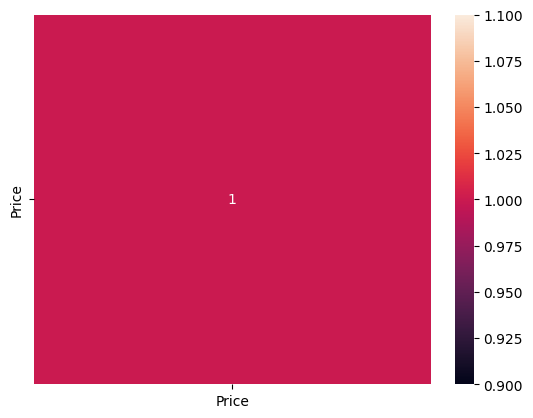

In [91]:
sns.heatmap(
    planes.corr(numeric_only=True),
    annot=True
)

In [92]:
planes.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [93]:
print(planes['Total_Stops'].value_counts())

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64


In [94]:
planes['Total_Stops'] = planes['Total_Stops'].str.replace(" stops",'', regex=False)
planes['Total_Stops'] = planes['Total_Stops'].str.replace(" stop",'', regex=False)
planes['Total_Stops'] = planes['Total_Stops'].str.replace("none-stop",'0', regex=False)

# Safely convert to numeric, fill missing values with the median, then convert to int
tmp = pd.to_numeric(planes['Total_Stops'], errors='coerce')
median_val = tmp.median()
if np.isnan(median_val):
	median_val = 0
median_val = int(median_val)

planes['Total_Stops'] = tmp.fillna(median_val).astype(int)
print(planes['Total_Stops'])


0        1
1        2
2        2
3        1
4        1
        ..
10678    1
10679    1
10680    1
10681    1
10682    2
Name: Total_Stops, Length: 10683, dtype: int64


In [95]:
planes['Duration'].isna().sum()

np.int64(0)

In [96]:
planes[['duration_hour', 'duration_minutes']] = planes['Duration'].str.split(' ', expand=True)

In [97]:
planes[['duration_hour','duration_minutes']] = (
    planes['Duration']
    .str.extract(r'(?:(\d+)h)?\s*(?:(\d+)m)?')
)

In [99]:
# Safely convert duration parts to integers: fill missing values with 0 then convert
planes[['duration_hour','duration_minutes']] = (
	planes[['duration_hour','duration_minutes']]
	.fillna(0)
	.astype(int)
)

In [101]:
planes['total_minutes'] = planes['duration_hour']*60 + planes['duration_minutes']

<Axes: >

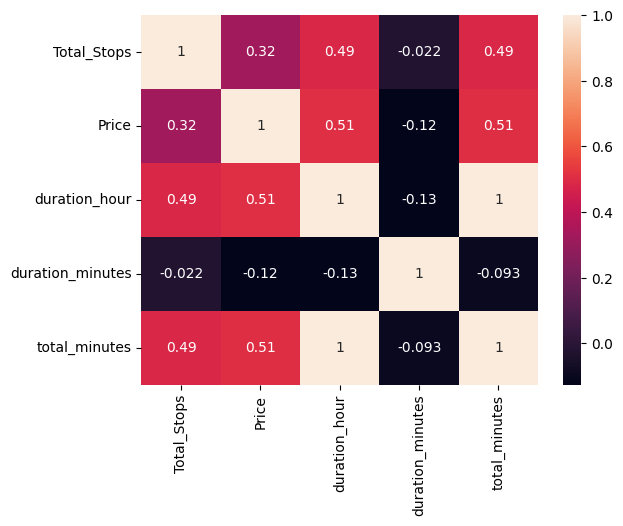

In [105]:
sns.heatmap(
    planes.corr(numeric_only=True),
    annot=True
)

In [121]:
planes['Date_of_Journey'] = pd.to_datetime(planes['Date_of_Journey'])

In [137]:
planes[['arr_hour','arr_minute']] = planes['Arrival_Time'].str.extract(r'(\d+):(\d+)')

In [133]:
planes['Arrival_Time']

0        01:10 22 Mar
1               13:15
2        04:25 10 Jun
3               23:30
4               21:35
             ...     
10678           22:25
10679           23:20
10680           11:20
10681           14:10
10682           19:15
Name: Arrival_Time, Length: 10683, dtype: str

In [136]:
planes['Dep_Time'] = pd.to_datetime(planes['Dep_Time'], format='%H:%M')

In [129]:
planes['month'] = planes['Date_of_Journey'].dt.month
planes['weekday'] = planes['Date_of_Journey'].dt.weekday

In [130]:
print(planes[['month','weekday','Date_of_Journey']].head())

   month  weekday Date_of_Journey
0      3        6      2019-03-24
1      5        2      2019-05-01
2      6        6      2019-06-09
3      5        6      2019-05-12
4      3        4      2019-03-01


In [140]:
planes['Dep_hour'] = planes['Dep_Time'].dt.hour
planes['Arrival_hour'] = planes['arr_hour'].astype(float)

In [142]:
twenty_fifth = planes['Price'].quantile(0.25)
median = planes['Price'].median()
seventy_fifth = planes['Price'].quantile(0.75)
maximum = planes['Price'].max()

In [147]:
labels = ['Economy','Premium Economy','Business Class','First Class']
bins = [0,twenty_fifth,median,seventy_fifth,maximum]


In [148]:
planes['Price Category'] = pd.cut(
    planes['Price'],
    labels=labels,
    bins=bins
)

In [149]:
print(planes[['Price','Price Category']].head())

   Price   Price Category
0   3897          Economy
1   7662  Premium Economy
2  13882      First Class
3   6218  Premium Economy
4  13302      First Class


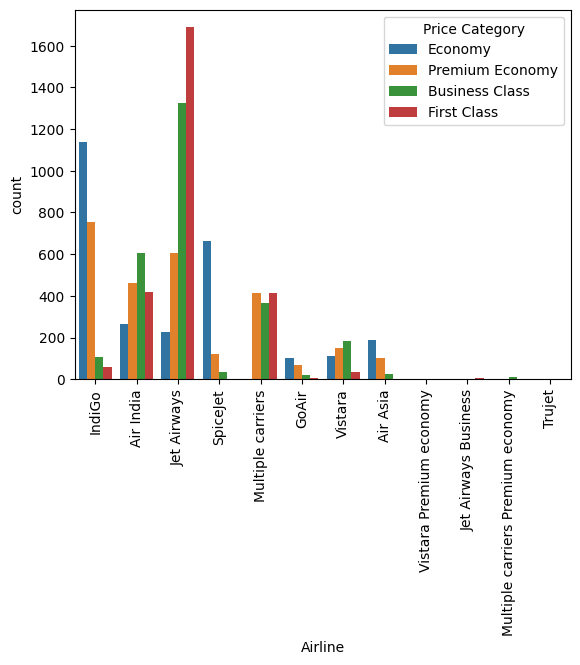

In [152]:
sns.countplot(
    data=planes,
    x='Airline',
    hue='Price Category'
)
plt.xticks(rotation=90)
plt.show()